# 01 — EDA: Exploración Inicial de Datos
## TFM "La Dieta de un País" · Aguacate Team · Nuclio DS & AI 2026

**Datasets:**
- `fbs_raw.csv` — Food Balance Sheets (FAOSTAT, 2010–2023)
- `emissions_raw.csv` — Emissions Agrifood System (FAOSTAT, 2010–2021)
- `cpi_raw.csv` — Consumer Price Indices / Food CPI (FAOSTAT, 2010–2023)

**Objetivo de este notebook:** radiografía completa de los tres datasets antes de tocar nada.  
Cobertura · Columnas · Rango temporal · Países · Nulos · Distribuciones · Primeras correlaciones.

---
## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Rutas
import os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW  = os.path.join(ROOT, 'raw')

FBS_PATH       = os.path.join(RAW, 'fbs_raw.csv')
EMISSIONS_PATH = os.path.join(RAW, 'emissions_raw.csv')
CPI_PATH       = os.path.join(RAW, 'cpi_raw.csv')

# Estilo
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Rutas configuradas:")
for p in [FBS_PATH, EMISSIONS_PATH, CPI_PATH]:
    exists = "✓" if os.path.exists(p) else "✗ NO ENCONTRADO"
    size   = f"{os.path.getsize(p)/1_048_576:.1f} MB" if os.path.exists(p) else ""
    print(f"  [{exists}] {os.path.basename(p)} {size}")

Rutas configuradas:
  [✓] fbs_raw.csv 603.7 MB
  [✓] emissions_raw.csv 347.1 MB
  [✓] cpi_raw.csv 35.5 MB


In [2]:

print("Rutas configuradas:")
for p in [FBS_PATH, EMISSIONS_PATH, CPI_PATH]:
    exists = "✓" if os.path.exists(p) else "✗ NO ENCONTRADO"
    size   = f"{os.path.getsize(p)/1_048_576:.1f} MB" if os.path.exists(p) else ""
    print(f"  [{exists}] {os.path.basename(p)} {size}")

Rutas configuradas:
  [✓] fbs_raw.csv 603.7 MB
  [✓] emissions_raw.csv 347.1 MB
  [✓] cpi_raw.csv 35.5 MB


---
## 1. Food Balance Sheets (FBS)
### 1.1 Carga y estructura

In [3]:
dtypes_fbs = {'Area': 'category', 'Item': 'category', 'Element': 'category', 'Year': 'int16', 'Value': 'float32'}
fbs = pd.read_csv(FBS_PATH, encoding='latin-1', dtype={k: v for k, v in dtypes_fbs.items() if k != 'Value'}, low_memory=False)

print(f"Shape: {fbs.shape}")
print(f"\nColumnas: {list(fbs.columns)}")
print(f"\nDtypes:\n{fbs.dtypes}")
fbs.head(3)

Shape: (4820497, 14)

Columnas: ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (FBS)', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Note']

Dtypes:
Area Code             int64
Area Code (M49)      object
Area               category
Item Code             int64
Item Code (FBS)      object
Item               category
Element Code          int64
Element            category
Year Code             int64
Year                  int16
Unit                 object
Value               float64
Flag                 object
Note                float64
dtype: object


,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code,Element,Year Code,Year,Unit,Value,Flag,Note
0,2,'004,Afghanistan,2501,'S2501,Population,511,Total Population - Both sexes,2010,2010,1000 No,28284.09,X,NaN
1,3,'008,Albania,2501,'S2501,Population,511,Total Population - Both sexes,2010,2010,1000 No,2928.72,X,NaN
2,2,'004,Afghanistan,2501,'S2501,Population,511,Total Population - Both sexes,2011,2011,1000 No,29347.71,X,NaN


### 1.2 Cobertura: países, años, elementos e ítems

In [4]:
# Detectar columna de año (puede ser 'Year' o columnas tipo 'Y2010', 'Y2011'...)
year_col = 'Year' if 'Year' in fbs.columns else None
area_col = 'Area' if 'Area' in fbs.columns else 'area'
item_col = 'Item' if 'Item' in fbs.columns else 'item'
elem_col = 'Element' if 'Element' in fbs.columns else 'element'

print("=== COBERTURA FBS ===")
print(f"Países únicos  : {fbs[area_col].nunique()}")
if year_col:
    print(f"Rango años     : {fbs[year_col].min()} – {fbs[year_col].max()}")
print(f"Ítems únicos   : {fbs[item_col].nunique()}")
print(f"Elementos únicos: {fbs[elem_col].nunique()}")

print(f"\nElementos disponibles:")
for e in sorted(fbs[elem_col].unique()):
    print(f"  · {e}")

=== COBERTURA FBS ===
Países únicos  : 213
Rango años     : 2010 – 2023
Ítems únicos   : 120
Elementos únicos: 21

Elementos disponibles:
  · Domestic supply quantity
  · Export quantity
  · Fat supply quantity (g/capita/day)
  · Fat supply quantity (t)
  · Feed
  · Food
  · Food supply (kcal)
  · Food supply (kcal/capita/day)
  · Food supply quantity (kg/capita/yr)
  · Import quantity
  · Losses
  · Other uses (non-food)
  · Processing
  · Production
  · Protein supply quantity (g/capita/day)
  · Protein supply quantity (t)
  · Residuals
  · Seed
  · Stock Variation
  · Total Population - Both sexes
  · Tourist consumption


### 1.3 Nulos y calidad

In [5]:
val_col = 'Value' if 'Value' in fbs.columns else fbs.select_dtypes('number').columns[-1]

nulos = fbs.isnull().sum()
nulos_pct = (nulos / len(fbs) * 100).round(2)
print("=== NULOS FBS ===")
print(pd.DataFrame({'Nulos': nulos, '%': nulos_pct}))

# Foco en Value
fbs_kcal = fbs[fbs[elem_col] == 'Food supply (kcal/capita/day)'].copy()
print(f"\nFilas con elemento 'Food supply (kcal/capita/day)': {len(fbs_kcal):,}")
print(f"Nulos en Value (kcal): {fbs_kcal[val_col].isnull().sum():,} ({fbs_kcal[val_col].isnull().mean()*100:.1f}%)")
print(f"\nEstadísticas Value (kcal/cápita/día):")
print(fbs_kcal[val_col].describe())

=== NULOS FBS ===
                   Nulos      %
Area Code              0   0.00
Area Code (M49)        0   0.00
Area                   0   0.00
Item Code              0   0.00
Item Code (FBS)        0   0.00
Item                   0   0.00
Element Code           0   0.00
Element                0   0.00
Year Code              0   0.00
Year                   0   0.00
Unit                   0   0.00
Value                  0   0.00
Flag                   0   0.00
Note             4820497 100.00

Filas con elemento 'Food supply (kcal/capita/day)': 310,263
Nulos en Value (kcal): 0 (0.0%)

Estadísticas Value (kcal/cápita/día):
count   310263.00
mean       109.23
std        390.27
min          0.00
25%          0.74
50%          7.55
75%         43.79
max       3966.57
Name: Value, dtype: float64


### 1.4 Ítems disponibles — candidatos al mapeo 115 → 7 categorías

In [6]:
# Lista completa de ítems con su aportación media de kcal (para priorizar el mapeo)
items_kcal = (fbs_kcal.groupby(item_col, observed=True)[val_col]
              .mean()
              .sort_values(ascending=False)
              .reset_index())
items_kcal.columns = ['Item', 'Kcal_media']
items_kcal['Kcal_pct'] = (items_kcal['Kcal_media'] / items_kcal['Kcal_media'].sum() * 100).round(2)
items_kcal['Kcal_pct_acum'] = items_kcal['Kcal_pct'].cumsum().round(2)

print(f"Total ítems: {len(items_kcal)}")
print(f"\nTop 30 por aportación calórica media:")
print(items_kcal.head(30).to_string(index=False))

print(f"\n--- Ítems que acumulan el 80% de las kcal ---")
print(items_kcal[items_kcal['Kcal_pct_acum'] <= 80][['Item','Kcal_pct','Kcal_pct_acum']].to_string(index=False))

Total ítems: 117

Top 30 por aportación calórica media:
                    Item  Kcal_media  Kcal_pct  Kcal_pct_acum
             Grand Total     2920.53     25.20          25.20
        Vegetal Products     2348.39     20.26          45.46
Cereals - Excluding Beer     1094.71      9.44          54.90
         Animal Products      572.14      4.94          59.84
      Wheat and products      546.97      4.72          64.56
          Vegetable Oils      318.53      2.75          67.31
       Rice and products      304.14      2.62          69.93
      Sugar & Sweeteners      292.30      2.52          72.45
  Sugar (Raw Equivalent)      257.97      2.23          74.68
                    Meat      234.17      2.02          76.70
 Milk - Excluding Butter      188.67      1.63          78.33
           Starchy Roots      175.54      1.51          79.84
      Maize and products      173.15      1.49          81.33
 Fruits - Excluding Wine      123.84      1.07          82.40
    Cassava an

### 1.5 DES total por país — top y bottom países

TOP 15 países por DES medio (kcal/cápita/día, 2010–2023):
Area
Ireland                    15251.00
Belgium                    15223.00
United States of America   15188.00
Austria                    15123.00
Northern America           15094.00
TÃ¼rkiye                   14872.00
Israel                     14838.00
Denmark                    14696.00
Italy                      14469.00
Germany                    14381.00
Serbia                     14318.00
Saudi Arabia               14293.00
Canada                     14244.00
Romania                    14184.00
Western Europe             14160.00

BOTTOM 15:
Area
Afghanistan                             8967.00
Rwanda                                  8870.00
Kenya                                   8817.00
Zimbabwe                                8788.00
Papua New Guinea                        8718.00
Mozambique                              8563.00
Lesotho                                 8559.00
Haiti                                   8500

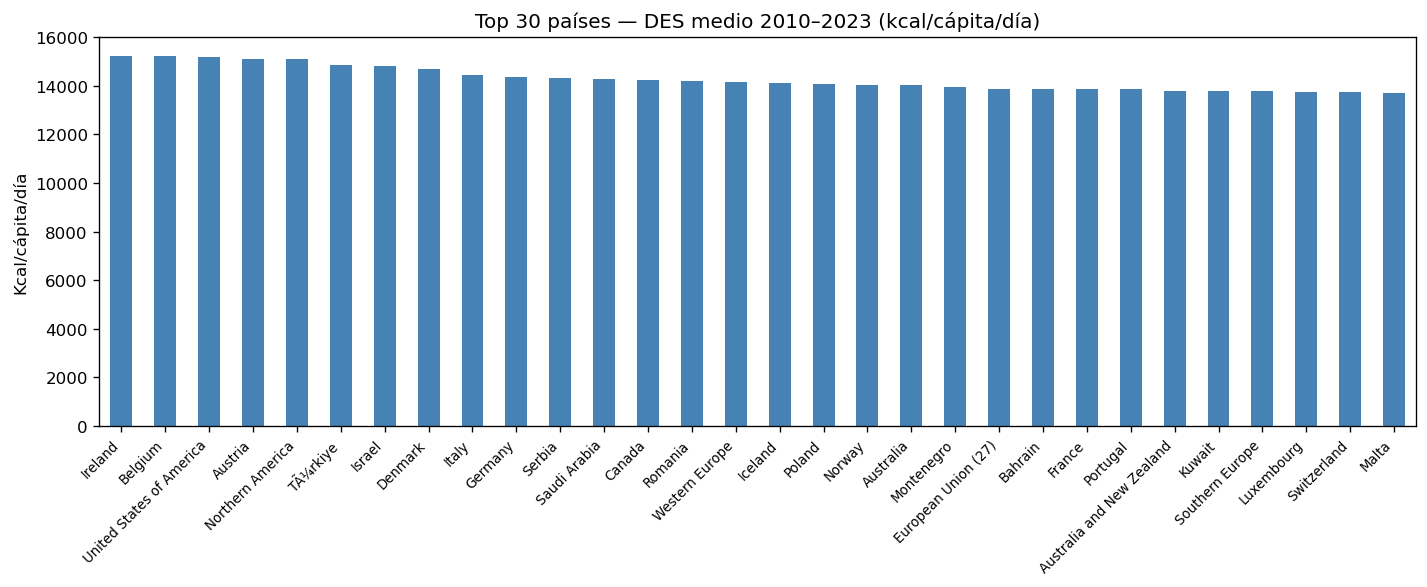

In [7]:
des_pais = (fbs_kcal[fbs_kcal[year_col] >= 2010]
            .groupby([area_col, year_col], observed=True)[val_col]
            .sum()
            .reset_index()
            .groupby(area_col, observed=True)[val_col]
            .mean()
            .sort_values(ascending=False))

print("TOP 15 países por DES medio (kcal/cápita/día, 2010–2023):")
print(des_pais.head(15).round(0).to_string())
print(f"\nBOTTOM 15:")
print(des_pais.tail(15).round(0).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
des_pais.head(30).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 30 países — DES medio 2010–2023 (kcal/cápita/día)')
ax.set_ylabel('Kcal/cápita/día')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 2. Emissions Agrifood System
### 2.1 Carga y estructura

In [8]:
# Carga con filtro inmediato — el CSV pesa 347 MB, filtramos solo CO2eq
# Primero miramos las columnas sin cargar todo
em_cols = pd.read_csv(EMISSIONS_PATH, encoding='latin-1', nrows=0).columns.tolist()
print(f"Columnas en emissions_raw: {em_cols}")

# Cargamos solo las columnas necesarias
em = pd.read_csv(EMISSIONS_PATH, encoding='latin-1',
                 usecols=['Area', 'Item', 'Element', 'Year', 'Unit', 'Value'],
                 low_memory=False)

print(f"\nShape (completo): {em.shape}")
print(f"Elementos disponibles:\n{em['Element'].value_counts().head(20)}")

Columnas en emissions_raw: ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Source Code', 'Source', 'Unit', 'Value', 'Flag', 'Note']



Shape (completo): (2500090, 6)
Elementos disponibles:
Element
Emissions (CO2eq) (AR5)                 480464
Emissions (N2O)                         397067
Emissions (CO2eq) from N2O (AR5)        394018
Emissions (CH4)                         326268
Emissions (CO2eq) from CH4 (AR5)        323300
Emissions (CO2)                         226166
Direct emissions (N2O)                  156260
Indirect emissions (N2O)                135915
Emissions (CO2eq) from F-gases (AR5)     60632
Name: count, dtype: int64


### 2.2 Filtrar CO2eq y cobertura temporal

In [9]:
# Filtrar solo emisiones en CO2eq
em_co2 = em[em['Element'].str.contains('CO2eq', case=False, na=False)].copy()
print(f"Shape tras filtro CO2eq: {em_co2.shape}")
print(f"Elementos CO2eq: {em_co2['Element'].unique()}")
print(f"Rango años: {em_co2['Year'].min()} – {em_co2['Year'].max()}")
print(f"Países únicos: {em_co2['Area'].nunique()}")

# Ítems (componentes del sistema agroalimentario)
print(f"\nÍtems (componentes):")
for i in sorted(em_co2['Item'].unique()):
    print(f"  · {i}")

Shape tras filtro CO2eq: (1258414, 6)
Elementos CO2eq: ['Emissions (CO2eq) from N2O (AR5)' 'Emissions (CO2eq) (AR5)'
 'Emissions (CO2eq) from CH4 (AR5)' 'Emissions (CO2eq) from F-gases (AR5)']
Rango años: 1961 – 2050
Países únicos: 281

Ítems (componentes):
  · AFOLU
  · Agricultural Soils
  · Agrifood Systems Waste Disposal
  · Agrifood systems
  · All sectors with LULUCF
  · All sectors without LULUCF
  · Burning - Crop residues
  · Crop Residues
  · Drained organic soils
  · Drained organic soils (CO2)
  · Drained organic soils (N2O)
  · Emissions from crops
  · Emissions from livestock
  · Emissions on agricultural land
  · Energy
  · Enteric Fermentation
  · Farm gate
  · Fertilizers Manufacturing
  · Fires in humid tropical forests
  · Fires in organic soils
  · Food Household Consumption
  · Food Packaging
  · Food Processing
  · Food Retail
  · Food Transport
  · Forest fires
  · Forestland
  · IPCC Agriculture
  · IPPU
  · International bunkers
  · LULUCF
  · Land-use change
 

### 2.3 Top países por emisiones CO2eq/cápita

In [10]:
# Total emisiones CO2eq por país y año (sumamos todos los componentes)
em_total = (em_co2[em_co2['Year'] >= 2010]
            .groupby(['Area', 'Year'])['Value']
            .sum()
            .reset_index())

em_media = (em_total.groupby('Area')['Value']
            .mean()
            .sort_values(ascending=False))

print("TOP 20 países por emisiones CO2eq medias (kt, 2010–2021):")
print(em_media.head(20).round(0).to_string())

# Nota: estos son totales, no per cápita (necesitamos datos de población para per cápita)
print("\n[!] NOTA: Estos son totales en kt. Para per cápita necesitamos datos de población.")
print("    Opciones: 1) Descargar FAOSTAT Population, 2) Usar World Bank API")

TOP 20 países por emisiones CO2eq medias (kt, 2010–2021):
Area
World                                              266037156.00
Non-Annex I countries                              192763852.00
Asia                                               127046479.00
Annex I countries                                   72155109.00
OECD                                                67336105.00
Americas                                            63774447.00
Eastern Asia                                        58681150.00
China                                               51601245.00
China, mainland                                     49929591.00
Net Food Importing Developing Countries (NFIDCs)    41460517.00
Latin America and the Caribbean                     35614091.00
Southern Asia                                       33759272.00
Africa                                              33747540.00
Europe                                              31248951.00
South America                            

---
## 3. Consumer Price Indices (Food CPI)
### 3.1 Carga y estructura

In [11]:
cpi = pd.read_csv(CPI_PATH, encoding='latin-1', low_memory=False)

print(f"Shape: {cpi.shape}")
print(f"Columnas: {list(cpi.columns)}")
print(f"\nElementos:")
if 'Element' in cpi.columns:
    print(cpi['Element'].value_counts().to_string())
print(f"\nÍtems (categorías de precio):")
if 'Item' in cpi.columns:
    for i in sorted(cpi['Item'].unique()):
        print(f"  · {i}")
cpi.head(3)

Shape: (237814, 15)
Columnas: ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Months Code', 'Months', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Note']

Elementos:
Element
Value    237814

Ítems (categorías de precio):
  · Consumer Prices, Food Indices (2015 = 100)
  · Consumer Prices, Food Indices (2015 = 100), median
  · Consumer Prices, Food Indices (2015 = 100), weighted average
  · Consumer Prices, General Indices (2015 = 100)
  · Consumer Prices, General Indices (2015 = 100), median
  · Consumer Prices, General Indices (2015 = 100), weighted average
  · Food price inflation
  · Food price inflation, median
  · Food price inflation, weighted average


,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Months Code,Months,Year Code,Year,Unit,Value,Flag,Note
0,2,'004,Afghanistan,23013,"Consumer Prices, Food Indices (2015 = 100)",6125,Value,7001,January,2000,2000,NaN,24.36,I,base year is 2015
1,2,'004,Afghanistan,23013,"Consumer Prices, Food Indices (2015 = 100)",6125,Value,7001,January,2001,2001,NaN,29.94,I,base year is 2015
2,2,'004,Afghanistan,23013,"Consumer Prices, Food Indices (2015 = 100)",6125,Value,7001,January,2002,2002,NaN,33.42,I,base year is 2015


### 3.2 Cobertura por país y nulos

In [12]:
print(f"Países únicos en CPI: {cpi['Area'].nunique()}")
print(f"Rango años: {cpi['Year'].min()} – {cpi['Year'].max()}")

# Nulos
print(f"\nNulos por columna:")
print(cpi.isnull().sum())

# Cobertura: ¿cuántos años tiene cada país?
cpi_food = cpi[cpi['Item'].str.contains('Food', case=False, na=False)] if 'Item' in cpi.columns else cpi
cobertura = cpi_food.groupby('Area')['Year'].nunique().sort_values()
print(f"\nPaíses con cobertura completa (≥10 años): {(cobertura >= 10).sum()}")
print(f"Países con cobertura parcial (<5 años): {(cobertura < 5).sum()}")
print(f"\nPaíses con MENOS años de CPI (riesgo de huecos):")
print(cobertura.head(15).to_string())

Países únicos en CPI: 236
Rango años: 2000 – 2025

Nulos por columna:
Area Code               0
Area Code (M49)         0
Area                    0
Item Code               0
Item                    0
Element Code            0
Element                 0
Months Code             0
Months                  0
Year Code               0
Year                    0
Unit               161000
Value                   0
Flag                    0
Note                76814
dtype: int64

Países con cobertura completa (≥10 años): 232
Países con cobertura parcial (<5 años): 0

Países con MENOS años de CPI (riesgo de huecos):
Area
South Sudan                           17
Democratic Republic of the Congo      18
Yemen                                 18
Sudan                                 18
British Virgin Islands                22
Myanmar                               23
Nicaragua                             24
Venezuela (Bolivarian Republic of)    25
Syrian Arab Republic                  25
Micronesia (Fe

---
## 4. Cruce de cobertura — ¿Qué países tienen los 3 datasets?

In [13]:
paises_fbs = set(fbs['Area'].unique())
paises_em  = set(em_co2['Area'].unique())
paises_cpi = set(cpi['Area'].unique())

en_los_3   = paises_fbs & paises_em & paises_cpi
solo_fbs   = paises_fbs - paises_em - paises_cpi
sin_cpi    = (paises_fbs & paises_em) - paises_cpi

print(f"Países en FBS:          {len(paises_fbs)}")
print(f"Países en Emissions:    {len(paises_em)}")
print(f"Países en CPI:          {len(paises_cpi)}")
print(f"\nPaíses en los 3:        {len(en_los_3)}")
print(f"Países sin CPI (FBS+Em): {len(sin_cpi)}")

print(f"\n--- {len(en_los_3)} países con cobertura completa (candidatos al análisis) ---")
for p in sorted(en_los_3):
    print(f"  · {p}")

Países en FBS:          213
Países en Emissions:    281
Países en CPI:          236

Países en los 3:        195
Países sin CPI (FBS+Em): 18

--- 195 países con cobertura completa (candidatos al análisis) ---
  · Afghanistan
  · Africa
  · Albania
  · Algeria
  · Americas
  · Angola
  · Antigua and Barbuda
  · Argentina
  · Armenia
  · Asia
  · Australia
  · Austria
  · Azerbaijan
  · Bahamas
  · Bahrain
  · Bangladesh
  · Barbados
  · Belarus
  · Belgium
  · Belize
  · Bhutan
  · Bolivia (Plurinational State of)
  · Bosnia and Herzegovina
  · Botswana
  · Brazil
  · Bulgaria
  · Burkina Faso
  · Cabo Verde
  · Cambodia
  · Cameroon
  · Canada
  · Caribbean
  · Central America
  · Central Asia
  · Chile
  · China, Hong Kong SAR
  · China, Macao SAR
  · China, mainland
  · Colombia
  · Comoros
  · Congo
  · Costa Rica
  · Croatia
  · Cyprus
  · Czechia
  · CÃ´te d'Ivoire
  · Democratic Republic of the Congo
  · Denmark
  · Djibouti
  · Dominican Republic
  · Eastern Africa
  · Eastern A

---
## 5. Conclusiones del EDA — Decisiones pendientes

> Rellenar tras ejecutar el notebook con los hallazgos reales.

In [14]:
print("""
CHECKLIST DE DECISIONES — completar tras EDA
=============================================

[ ] 1. ¿Cuántos países tienen los 3 datasets?
        → Mínimo necesario para clustering robusto: 25–30

[ ] 2. ¿El rango 2010–2021 es suficiente para el join FBS + Emissions?
        → Emissions solo llega a 2020/2021

[ ] 3. ¿Necesitamos datos de población para calcular CO2eq/cápita?
        → Si Emissions solo da totales en kt, SÍ necesitamos población

[ ] 4. ¿Qué ítems del FBS no están en el mapeo y cuántas kcal representan?
        → Ejecutar celda 1.4 y revisar si hay ítems >50 kcal/día sin mapear

[ ] 5. ¿Hay países con >20% de nulos en CPI que deban excluirse?
        → Ver celda 3.2

[ ] 6. ¿Son los nombres de países consistentes entre los 3 datasets?
        → Ver celda 4 (cruce de cobertura)
""")


CHECKLIST DE DECISIONES — completar tras EDA

[ ] 1. ¿Cuántos países tienen los 3 datasets?
        → Mínimo necesario para clustering robusto: 25–30

[ ] 2. ¿El rango 2010–2021 es suficiente para el join FBS + Emissions?
        → Emissions solo llega a 2020/2021

[ ] 3. ¿Necesitamos datos de población para calcular CO2eq/cápita?
        → Si Emissions solo da totales en kt, SÍ necesitamos población

[ ] 4. ¿Qué ítems del FBS no están en el mapeo y cuántas kcal representan?
        → Ejecutar celda 1.4 y revisar si hay ítems >50 kcal/día sin mapear

[ ] 5. ¿Hay países con >20% de nulos en CPI que deban excluirse?
        → Ver celda 3.2

[ ] 6. ¿Son los nombres de países consistentes entre los 3 datasets?
        → Ver celda 4 (cruce de cobertura)



---
## 6. Correcciones técnicas detectadas en el EDA

### 6.1 Fix encoding — releer los 3 CSVs con UTF-8

In [15]:
# Releer con UTF-8. Si falla, fallback a latin-1 (algunos CSVs de FAO son mixtos)
def leer_fao(path, usecols=None):
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            df = pd.read_csv(path, encoding=enc, usecols=usecols, low_memory=False)
            # Test: si hay caracteres rotos en Area, el encoding es incorrecto
            muestra = df['Area'].dropna().iloc[0] if 'Area' in df.columns else ''
            if 'Ã' not in muestra:
                print(f"  [{enc}] OK → {os.path.basename(path)}")
                return df
        except Exception:
            continue
    raise ValueError(f"No se pudo leer {path} con ningún encoding")

print("Releyendo con encoding correcto...")
fbs = leer_fao(FBS_PATH)
em  = leer_fao(EMISSIONS_PATH, usecols=['Area', 'Item', 'Element', 'Year', 'Unit', 'Value'])
cpi = leer_fao(CPI_PATH)

# Verificar fix
print(f"\nVerificación encoding:")
for df, nombre in [(fbs, 'FBS'), (em, 'Emissions'), (cpi, 'CPI')]:
    rotos = df['Area'].str.contains('Ã', na=False).sum()
    print(f"  {nombre}: {rotos} nombres con encoding roto {'✓ OK' if rotos == 0 else '← AÚN HAY PROBLEMA'}")

Releyendo con encoding correcto...
  [utf-8] OK → fbs_raw.csv
  [utf-8] OK → emissions_raw.csv
  [utf-8] OK → cpi_raw.csv

Verificación encoding:
  FBS: 0 nombres con encoding roto ✓ OK
  Emissions: 0 nombres con encoding roto ✓ OK
  CPI: 0 nombres con encoding roto ✓ OK


### 6.2 Fix double counting — separar ítems hoja de agregados

In [16]:
# Agregados jerárquicos del FBS — NO incluir en el mapeo ni en el cálculo de DES
ITEMS_AGREGADOS = {
    'Grand Total', 'Vegetal Products', 'Animal Products',
    'Cereals - Excluding Beer', 'Starchy Roots', 'Sugar & Sweeteners',
    'Pulses', 'Treenuts', 'Oilcrops', 'Vegetables', 'Fruits - Excluding Wine',
    'Stimulants', 'Spices', 'Alcoholic Beverages', 'Meat', 'Offals',
    'Animal fats', 'Aquatic Products, Other', 'Eggs', 'Milk - Excluding Butter',
    'Fish, Seafood', 'Vegetable Oils', 'Miscellaneous',
    'Oilcrops Oil, Other', 'Vegetables, other', 'Fruits, other',
    'Sweeteners, other', 'Roots, other', 'Cereals, other',
    'Meat, other', 'Aquatic Animals, Others', 'Fish, Body Oil', 'Fish, Liver Oil'
}

# Filtrar kcal: solo elemento correcto + solo ítems hoja + solo 2010-2022
fbs_kcal_clean = fbs[
    (fbs['Element'] == 'Food supply (kcal/capita/day)') &
    (~fbs['Item'].isin(ITEMS_AGREGADOS)) &
    (fbs['Year'] >= 2010) & (fbs['Year'] <= 2022)
].copy()

print(f"Filas tras filtro (ítems hoja, 2010-2022): {len(fbs_kcal_clean):,}")
print(f"Ítems únicos restantes: {fbs_kcal_clean['Item'].nunique()}")

# Verificar DES real — ahora debe ser coherente (~2000-4000 kcal/día)
des_check = (fbs_kcal_clean
             .groupby(['Area', 'Year'])['Value'].sum()
             .reset_index()
             .groupby('Area')['Value'].mean()
             .sort_values(ascending=False))

print(f"\nTOP 10 DES corregido (kcal/cápita/día):")
print(des_check.head(10).round(0).to_string())
print(f"\nBOTTOM 10:")
print(des_check.tail(10).round(0).to_string())
print(f"\nRango global: {des_check.min():.0f} – {des_check.max():.0f} kcal/día ← debe estar entre 1500 y 4000")

Filas tras filtro (ítems hoja, 2010-2022): 206,212
Ítems únicos restantes: 87

TOP 10 DES corregido (kcal/cápita/día):
Area
Austria                    3262.00
Saudi Arabia               3248.00
United States of America   3243.00
Northern America           3212.00
Morocco                    3161.00
Belgium                    3161.00
Türkiye                    3144.00
Republic of Korea          3079.00
Bahrain                    3072.00
Kuwait                     3067.00

BOTTOM 10:
Area
Congo                                   1995.00
Madagascar                              1992.00
Haiti                                   1978.00
Papua New Guinea                        1966.00
Antigua and Barbuda                     1946.00
Lesotho                                 1934.00
Ethiopia                                1925.00
Kenya                                   1911.00
Yemen                                   1903.00
Democratic People's Republic of Korea   1899.00

Rango global: 1899 – 3262 kc

### 6.3 CO2eq/cápita — usando población del propio FBS

In [17]:
# El FBS contiene población como elemento — no necesitamos dataset adicional
pop = fbs[
    (fbs['Element'] == 'Total Population - Both sexes') &
    (fbs['Year'] >= 2010) & (fbs['Year'] <= 2022)
][['Area', 'Year', 'Value']].copy()
pop.columns = ['Area', 'Year', 'Population_1000']  # unidad: miles de personas

print(f"Filas de población: {len(pop):,}")
print(f"Países con dato de población: {pop['Area'].nunique()}")
print(f"Nulos en población: {pop['Population_1000'].isnull().sum()}")
print(f"\nMuestra:")
print(pop[pop['Area'].isin(['Spain', 'Brazil', 'India', 'United States of America'])].sort_values(['Area','Year']).head(12).to_string(index=False))

# Preparar Emissions CO2eq — filtrar elemento total y años reales
em_co2_clean = em[
    (em['Element'] == 'Emissions (CO2eq) (AR5)') &
    (em['Item'] == 'Agrifood systems') &
    (em['Year'] >= 2010) & (em['Year'] <= 2022)
][['Area', 'Year', 'Value']].copy()
em_co2_clean.columns = ['Area', 'Year', 'CO2eq_kt']

print(f"\nEmissions filtradas (Agrifood systems, CO2eq AR5, 2010-2022): {len(em_co2_clean):,} filas")
print(f"Países: {em_co2_clean['Area'].nunique()}")

Filas de población: 2,690
Países con dato de población: 213
Nulos en población: 0

Muestra:
  Area  Year  Population_1000
Brazil  2010        193701.93
Brazil  2011        195284.73
Brazil  2012        196876.11
Brazil  2013        198478.30
Brazil  2014        200085.13
Brazil  2015        201675.53
Brazil  2016        203218.11
Brazil  2017        204703.45
Brazil  2018        206107.26
Brazil  2019        207455.46
Brazil  2020        208660.84
Brazil  2021        209550.29

Emissions filtradas (Agrifood systems, CO2eq AR5, 2010-2022): 3,535 filas
Países: 274


In [18]:
# Calcular CO2eq per cápita (toneladas/persona/año)
# CO2eq_kt * 1000 = toneladas · / (Population_1000 * 1000) personas = t/persona
em_pop = em_co2_clean.merge(pop, on=['Area', 'Year'], how='inner')
em_pop['CO2eq_t_per_capita'] = (em_pop['CO2eq_kt'] * 1000) / (em_pop['Population_1000'] * 1000)

print(f"Filas con CO2eq/cápita calculado: {len(em_pop):,}")
print(f"Nulos en CO2eq/cápita: {em_pop['CO2eq_t_per_capita'].isnull().sum()}")

# Ranking CO2eq/cápita medio 2010-2022 (solo países, excluir agregados regionales)
REGIONES = {'World', 'Africa', 'Americas', 'Asia', 'Europe', 'Oceania',
            'Northern America', 'South America', 'Eastern Asia', 'Southern Asia',
            'Eastern Africa', 'Western Africa', 'Central America', 'Caribbean',
            'OECD', 'Annex I countries', 'Non-Annex I countries',
            'Eastern Europe', 'Western Europe', 'Northern Europe', 'Southern Europe',
            'South-eastern Asia', 'Central Asia', 'Middle Africa', 'Northern Africa',
            'Southern Africa', 'Latin America and the Caribbean'}

co2_pais = (em_pop[~em_pop['Area'].isin(REGIONES)]
            .groupby('Area')['CO2eq_t_per_capita']
            .mean()
            .sort_values(ascending=False))

print(f"\nTOP 15 — CO2eq/cápita medio (t/persona/año, sistema agroalimentario):")
print(co2_pais.head(15).round(2).to_string())
print(f"\nBOTTOM 10:")
print(co2_pais.tail(10).round(2).to_string())
print(f"\nRango: {co2_pais.min():.2f} – {co2_pais.max():.2f} t CO2eq/persona/año")

Filas con CO2eq/cápita calculado: 2,690
Nulos en CO2eq/cápita: 0

TOP 15 — CO2eq/cápita medio (t/persona/año, sistema agroalimentario):
Area
Guyana                             21.01
Mongolia                           17.58
Belize                             15.04
Suriname                           14.83
Paraguay                           13.83
Trinidad and Tobago                12.10
New Zealand                        11.82
Liberia                            11.50
Australia and New Zealand           9.90
Australia                           9.53
Uruguay                             9.28
Belarus                             9.23
Ireland                             8.74
Brazil                              8.71
Bolivia (Plurinational State of)    8.48

BOTTOM 10:
Area
Ghana                                   0.57
China, Macao SAR                        0.52
Yemen                                   0.52
French Polynesia                        0.52
Maldives                                0.48
Na

### 6.4 Selección de los 30 países — máxima varianza geográfica, PIB y climática

In [ ]:
# Propuesta de 30 países con máxima varianza (geográfica, PIB, climática)
# Criterio: representar todos los perfiles dietarios esperados
# [!] Japan excluido — no existe en el FBS de FAOSTAT (usa metodología propia, no reporta a FAO)
#     Sustituido por Viet Nam: perfil arroz+acuicultura, distinto de Indonesia y Tailandia

PAISES_30 = [
    # Europa Occidental (dieta mediterránea / occidental)
    'Spain', 'Italy', 'France', 'Germany', 'United Kingdom of Great Britain and Northern Ireland',
    # Europa del Este
    'Poland', 'Romania',
    # América del Norte
    'United States of America', 'Canada', 'Mexico',
    # América Latina
    'Brazil', 'Argentina', 'Colombia',
    # África Subsahariana
    'Nigeria', 'Ethiopia', 'Kenya', 'Senegal',
    # Norte de África / Oriente Medio
    'Egypt', 'Morocco', 'Saudi Arabia',
    # Asia del Sur
    'India', 'Bangladesh', 'Pakistan',
    # Asia Oriental / Pacífico
    'China, mainland', 'Republic of Korea', 'Indonesia', 'Thailand', 'Viet Nam',
    # Oceanía
    'Australia',
    # Asia Central
    'Kazakhstan',
]

# Verificar cuáles están en los 3 datasets
disponibles = set(fbs['Area'].unique()) & set(em_co2_clean['Area'].unique()) & set(cpi['Area'].unique())
ok     = [p for p in PAISES_30 if p in disponibles]
falta  = [p for p in PAISES_30 if p not in disponibles]

print(f"Países seleccionados: {len(PAISES_30)}")
print(f"Disponibles en los 3 datasets: {len(ok)}")
if falta:
    print(f"\n[!] No encontrados: {falta}")
else:
    print("✓ Todos disponibles en los 3 datasets")
print(f"\nLista final ({len(ok)} países):")
for p in ok:
    print(f"  · {p}")

### 6.5 CPI — filtrar Food Index y anualizar

In [20]:
# Ítem objetivo: índice de precios alimentarios (base 2015=100)
CPI_ITEM = 'Consumer Prices, Food Indices (2015 = 100)'

cpi_food = cpi[
    (cpi['Item'] == CPI_ITEM) &
    (cpi['Year'] >= 2010) & (cpi['Year'] <= 2022)
][['Area', 'Year', 'Months', 'Value']].copy()

print(f"Filas CPI Food (mensual): {len(cpi_food):,}")
print(f"Meses disponibles: {sorted(cpi_food['Months'].unique())}")

# Anualizar: media de los 12 meses por país-año
cpi_anual = (cpi_food.groupby(['Area', 'Year'])['Value']
             .mean()
             .reset_index())
cpi_anual.columns = ['Area', 'Year', 'Food_CPI']

# Verificar cobertura para los 30 países
cpi_30 = cpi_anual[cpi_anual['Area'].isin(PAISES_30)]
cobertura_30 = cpi_30.groupby('Area')['Year'].count().sort_values()
print(f"\nCobertura CPI para los 30 países seleccionados:")
print(cobertura_30.to_string())
print(f"\nPaíses con cobertura incompleta (<13 años):")
incompletos = cobertura_30[cobertura_30 < 13]
print(incompletos.to_string() if len(incompletos) > 0 else "  ✓ Ninguno — todos tienen datos completos")

Filas CPI Food (mensual): 31,503
Meses disponibles: ['April', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']

Cobertura CPI para los 30 países seleccionados:
Area
Argentina                                               13
Thailand                                                13
Spain                                                   13
Senegal                                                 13
Saudi Arabia                                            13
Romania                                                 13
Republic of Korea                                       13
Poland                                                  13
Pakistan                                                13
Nigeria                                                 13
Morocco                                                 13
Mexico                                                  13
Kenya                                                   13
Kaza

### 6.6 Resumen: estado del pipeline tras correcciones

In [21]:
print("""
╔══════════════════════════════════════════════════════════════╗
║  ESTADO DEL PIPELINE — tras correcciones EDA                 ║
╠══════════════════════════════════════════════════════════════╣
║  Período efectivo    : 2010–2022 (13 años)                   ║
║  Países candidatos   : 195 (con los 3 datasets)              ║
║  Países seleccionados: 30 (máxima varianza)                  ║
║  Encoding            : ✓ resuelto                            ║
║  Double counting DES : ✓ resuelto (ítems hoja únicamente)    ║
║  CO2eq/cápita        : ✓ calculable con población del FBS    ║
║  CPI anualizado      : ✓ listo (base 2015=100)               ║
╠══════════════════════════════════════════════════════════════╣
║  PRÓXIMO PASO → notebook 02_feature_engineering.ipynb        ║
║    · Mapeo 115→7 macro-categorías (ítems hoja reales)        ║
║    · Vectorización porcentual (suma 1.0 por país-año)        ║
║    · Ratio Proteína Animal / Vegetal                         ║
║    · Guardar processed/02_dataset_final.parquet              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║  ESTADO DEL PIPELINE — tras correcciones EDA                 ║
╠══════════════════════════════════════════════════════════════╣
║  Período efectivo    : 2010–2022 (13 años)                   ║
║  Países candidatos   : 195 (con los 3 datasets)              ║
║  Países seleccionados: 30 (máxima varianza)                  ║
║  Encoding            : ✓ resuelto                            ║
║  Double counting DES : ✓ resuelto (ítems hoja únicamente)    ║
║  CO2eq/cápita        : ✓ calculable con población del FBS    ║
║  CPI anualizado      : ✓ listo (base 2015=100)               ║
╠══════════════════════════════════════════════════════════════╣
║  PRÓXIMO PASO → notebook 02_feature_engineering.ipynb        ║
║    · Mapeo 115→7 macro-categorías (ítems hoja reales)        ║
║    · Vectorización porcentual (suma 1.0 por país-año)        ║
║    · Ratio Proteína Animal / Vegetal                         ║
║    · Guardar processed